In [3]:
# STEP 0: Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [4]:
# STEP 1: Load CSV (Dataset Collection)
df = pd.read_csv("C:\\Users\\harid\\Downloads\\Practicum-1\\listings_detailed.csv")
print("Initial dataset shape:", df.shape)

Initial dataset shape: (6455, 75)


In [5]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [6]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,22229408,https://www.airbnb.com/rooms/22229408,20230319041206,2023-03-19,previous scrape,"Explorer's Paradise: Near Train, Bus & Bike Share",Welcome to your perfect urban escape in the Na...,My home is located in the Edgewood neighborhoo...,https://a0.muscache.com/pictures/8e49b7bc-a851...,120875011,...,4.85,4.75,4.75,NaN,f,1,0,1,0,0.32
1,46951758,https://www.airbnb.com/rooms/46951758,20230319041206,2023-03-19,city scrape,Boutique Style Home - Rooftop w/Breathtaking V...,Explore or get settled in this artsy modern ro...,"Food & Drinks: Starbucks, Mama's Pizza, Busboy...",https://a0.muscache.com/pictures/miso/Hosting-...,55133178,...,4.82,4.51,4.80,Hosted License: 5007242201002380\nUnhosted Lic...,f,1,1,0,0,1.87
2,580379638076900630,https://www.airbnb.com/rooms/580379638076900630,20230319041206,2023-03-19,city scrape,Sojourn | Penthouse | Private Outdoor Space | ...,Boutique building in one of DC's best neighbor...,Dupont Circle stands out as a cosmopolitan jew...,https://a0.muscache.com/pictures/prohost-api/H...,39930655,...,NaN,NaN,NaN,NaN,f,173,154,13,5,NaN
3,594971943284098653,https://www.airbnb.com/rooms/594971943284098653,20230319041206,2023-03-19,city scrape,Quaint 1-bedroom apartment with outdoor Patio,Welcome to the center of DC. Half-way between ...,NaN,https://a0.muscache.com/pictures/5746a258-d2f7...,351398058,...,5.00,4.73,4.73,Hosted License: 5007242201002106\nUnhosted Lic...,t,3,2,1,0,1.20
4,54371126,https://www.airbnb.com/rooms/54371126,20230319041206,2023-03-19,city scrape,Waterfront Two Bedroom Apartment In a Brand Ne...,Located in Washington in the District of Colum...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,395672427,...,5.00,5.00,5.00,Unhosted License: 5007242100000024,t,7,7,0,0,0.48


In [7]:
df.tail()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
6450,849293688249908869,https://www.airbnb.com/rooms/849293688249908869,20230319041206,2023-03-19,city scrape,Top-floor Glover Park apartment,Enjoy this centrally located Washington DC Apa...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,9286163,...,NaN,NaN,NaN,Hosted License: 5007242201002035,f,5,1,4,0,NaN
6451,849304474004984024,https://www.airbnb.com/rooms/849304474004984024,20230319041206,2023-03-19,city scrape,5 Bedroom 3 Story Townhome in DC,Welcome to your next memorable Airbnb experien...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,140334352,...,NaN,NaN,NaN,Hosted License: 5007242201001806,f,7,4,3,0,NaN
6452,849310766288741827,https://www.airbnb.com/rooms/849310766288741827,20230319041206,2023-03-19,city scrape,2 br U st Condo with rooftop,This spacious two bedroom condo is walking dis...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,177084854,...,NaN,NaN,NaN,Exempt,t,1,1,0,0,NaN
6453,849479534479786096,https://www.airbnb.com/rooms/849479534479786096,20230319041206,2023-03-19,city scrape,cozy Suite on Rhode Island IIII,Come enjoy a private room inside of a two bedr...,NaN,https://a0.muscache.com/pictures/921e5414-2631...,390256204,...,NaN,NaN,NaN,Exempt,t,45,16,28,1,NaN
6454,849521381332726773,https://www.airbnb.com/rooms/849521381332726773,20230319041206,2023-03-19,city scrape,Charm Chic Cozy Apartment DC,"Welcome to our quaint, stylish apartment in th...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,505882163,...,NaN,NaN,NaN,Hosted License: 5007242201002658,t,1,1,0,0,NaN


In [8]:
df.shape

(6455, 75)

In [9]:
df.size

484125

In [10]:
# STEP 2: Drop URLs, IDs, and Text Columns (Noise Removal)
drop_cols = [
    # IDs & URLs
    'id','listing_url','scrape_id','picture_url',
    'host_url','host_thumbnail_url','host_picture_url',

    # Long / noisy text
    'name','description','neighborhood_overview',
    'host_about','source','calendar_updated','license',

    # Dates not used directly
    'last_scraped','calendar_last_scraped',

    # Free-text / identifiers
    'host_name','host_location','host_neighbourhood',
    'neighbourhood'
]
df.drop(columns=drop_cols, inplace=True, errors='ignore')

In [11]:
df.head()

,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,120875011,2017-03-15,NaN,NaN,NaN,f,1,2,"['email', 'phone']",t,...,4.95,4.85,4.75,4.75,f,1,0,1,0,0.32
1,55133178,2016-01-18,within an hour,100%,100%,f,1,2,"['email', 'phone']",t,...,4.86,4.82,4.51,4.80,f,1,1,0,0,1.87
2,39930655,2015-07-29,within an hour,99%,100%,f,251,289,"['email', 'phone']",t,...,NaN,NaN,NaN,NaN,f,173,154,13,5,NaN
3,351398058,2020-06-22,within an hour,100%,100%,t,3,4,"['email', 'phone']",t,...,4.91,5.00,4.73,4.73,t,3,2,1,0,1.20
4,395672427,2021-04-05,NaN,NaN,NaN,f,1408,2586,"['email', 'phone']",t,...,5.00,5.00,5.00,5.00,t,7,7,0,0,0.48


In [12]:
# STEP 3: Price Cleaning – Remove $ and Commas
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [13]:
df.head()

,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,120875011,2017-03-15,NaN,NaN,NaN,f,1,2,"['email', 'phone']",t,...,4.95,4.85,4.75,4.75,f,1,0,1,0,0.32
1,55133178,2016-01-18,within an hour,100%,100%,f,1,2,"['email', 'phone']",t,...,4.86,4.82,4.51,4.80,f,1,1,0,0,1.87
2,39930655,2015-07-29,within an hour,99%,100%,f,251,289,"['email', 'phone']",t,...,NaN,NaN,NaN,NaN,f,173,154,13,5,NaN
3,351398058,2020-06-22,within an hour,100%,100%,t,3,4,"['email', 'phone']",t,...,4.91,5.00,4.73,4.73,t,3,2,1,0,1.20
4,395672427,2021-04-05,NaN,NaN,NaN,f,1408,2586,"['email', 'phone']",t,...,5.00,5.00,5.00,5.00,t,7,7,0,0,0.48


In [14]:
# STEP 4: Remove Zero / Invalid Prices
df = df[df['price'] > 0]

In [15]:
df.head()

,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,120875011,2017-03-15,NaN,NaN,NaN,f,1,2,"['email', 'phone']",t,...,4.95,4.85,4.75,4.75,f,1,0,1,0,0.32
1,55133178,2016-01-18,within an hour,100%,100%,f,1,2,"['email', 'phone']",t,...,4.86,4.82,4.51,4.80,f,1,1,0,0,1.87
2,39930655,2015-07-29,within an hour,99%,100%,f,251,289,"['email', 'phone']",t,...,NaN,NaN,NaN,NaN,f,173,154,13,5,NaN
3,351398058,2020-06-22,within an hour,100%,100%,t,3,4,"['email', 'phone']",t,...,4.91,5.00,4.73,4.73,t,3,2,1,0,1.20
4,395672427,2021-04-05,NaN,NaN,NaN,f,1408,2586,"['email', 'phone']",t,...,5.00,5.00,5.00,5.00,t,7,7,0,0,0.48


In [16]:
# STEP 5: Outlier Removal Using IQR
Q1, Q3 = df['price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df = df[(df['price'] >= Q1 - 1.5 * IQR) &
        (df['price'] <= Q3 + 1.5 * IQR)]

In [17]:
df.head()

,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,120875011,2017-03-15,NaN,NaN,NaN,f,1,2,"['email', 'phone']",t,...,4.95,4.85,4.75,4.75,f,1,0,1,0,0.32
1,55133178,2016-01-18,within an hour,100%,100%,f,1,2,"['email', 'phone']",t,...,4.86,4.82,4.51,4.80,f,1,1,0,0,1.87
2,39930655,2015-07-29,within an hour,99%,100%,f,251,289,"['email', 'phone']",t,...,NaN,NaN,NaN,NaN,f,173,154,13,5,NaN
3,351398058,2020-06-22,within an hour,100%,100%,t,3,4,"['email', 'phone']",t,...,4.91,5.00,4.73,4.73,t,3,2,1,0,1.20
4,395672427,2021-04-05,NaN,NaN,NaN,f,1408,2586,"['email', 'phone']",t,...,5.00,5.00,5.00,5.00,t,7,7,0,0,0.48


In [18]:
# STEP 6: Fix Percentage Columns (Type Correction)
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df.columns:
        df[col] = df[col].str.replace('%', '', regex=False).astype(float)

In [19]:
df.head()

,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,120875011,2017-03-15,NaN,NaN,NaN,f,1,2,"['email', 'phone']",t,...,4.95,4.85,4.75,4.75,f,1,0,1,0,0.32
1,55133178,2016-01-18,within an hour,100.0,100.0,f,1,2,"['email', 'phone']",t,...,4.86,4.82,4.51,4.80,f,1,1,0,0,1.87
2,39930655,2015-07-29,within an hour,99.0,100.0,f,251,289,"['email', 'phone']",t,...,NaN,NaN,NaN,NaN,f,173,154,13,5,NaN
3,351398058,2020-06-22,within an hour,100.0,100.0,t,3,4,"['email', 'phone']",t,...,4.91,5.00,4.73,4.73,t,3,2,1,0,1.20
4,395672427,2021-04-05,NaN,NaN,NaN,f,1408,2586,"['email', 'phone']",t,...,5.00,5.00,5.00,5.00,t,7,7,0,0,0.48


In [20]:
# STEP 7: Convert Boolean t/f Columns to 1/0
bool_cols = [
    'host_is_superhost',
    'host_has_profile_pic',
    'host_identity_verified',
    'instant_bookable',
    'has_availability'
]

for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].map({'t': 1, 'f': 0})

In [21]:
df.head()

,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,120875011,2017-03-15,NaN,NaN,NaN,0,1,2,"['email', 'phone']",1,...,4.95,4.85,4.75,4.75,0,1,0,1,0,0.32
1,55133178,2016-01-18,within an hour,100.0,100.0,0,1,2,"['email', 'phone']",1,...,4.86,4.82,4.51,4.80,0,1,1,0,0,1.87
2,39930655,2015-07-29,within an hour,99.0,100.0,0,251,289,"['email', 'phone']",1,...,NaN,NaN,NaN,NaN,0,173,154,13,5,NaN
3,351398058,2020-06-22,within an hour,100.0,100.0,1,3,4,"['email', 'phone']",1,...,4.91,5.00,4.73,4.73,1,3,2,1,0,1.20
4,395672427,2021-04-05,NaN,NaN,NaN,0,1408,2586,"['email', 'phone']",1,...,5.00,5.00,5.00,5.00,1,7,7,0,0,0.48


In [22]:
# STEP 8: Convert host_since Date to Numeric Experience
df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
df['host_experience_years'] = (
    (pd.Timestamp.today() - df['host_since']).dt.days / 365
)
df.drop(columns=['host_since'], inplace=True)

In [23]:
df.head()

,host_id,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_experience_years
0,120875011,NaN,NaN,NaN,0,1,2,"['email', 'phone']",1,0,...,4.85,4.75,4.75,0,1,0,1,0,0.32,8.986301
1,55133178,within an hour,100.0,100.0,0,1,2,"['email', 'phone']",1,1,...,4.82,4.51,4.80,0,1,1,0,0,1.87,10.142466
2,39930655,within an hour,99.0,100.0,0,251,289,"['email', 'phone']",1,1,...,NaN,NaN,NaN,0,173,154,13,5,NaN,10.616438
3,351398058,within an hour,100.0,100.0,1,3,4,"['email', 'phone']",1,1,...,5.00,4.73,4.73,1,3,2,1,0,1.20,5.712329
4,395672427,NaN,NaN,NaN,0,1408,2586,"['email', 'phone']",1,0,...,5.00,5.00,5.00,1,7,7,0,0,0.48,4.926027


In [24]:
# STEP 9: Drop Columns with High Missing Values (> 40%)
missing_ratio = df.isnull().mean()
df.drop(columns=missing_ratio[missing_ratio > 0.4].index, inplace=True)

In [25]:
df.head()

,host_id,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_experience_years
0,120875011,NaN,NaN,NaN,0,1,2,"['email', 'phone']",1,0,...,4.85,4.75,4.75,0,1,0,1,0,0.32,8.986301
1,55133178,within an hour,100.0,100.0,0,1,2,"['email', 'phone']",1,1,...,4.82,4.51,4.80,0,1,1,0,0,1.87,10.142466
2,39930655,within an hour,99.0,100.0,0,251,289,"['email', 'phone']",1,1,...,NaN,NaN,NaN,0,173,154,13,5,NaN,10.616438
3,351398058,within an hour,100.0,100.0,1,3,4,"['email', 'phone']",1,1,...,5.00,4.73,4.73,1,3,2,1,0,1.20,5.712329
4,395672427,NaN,NaN,NaN,0,1408,2586,"['email', 'phone']",1,0,...,5.00,5.00,5.00,1,7,7,0,0,0.48,4.926027


In [26]:
# STEP 10: Handle Missing Values (Imputation)
# Numerical → Median
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical → 'Unknown'
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('Unknown')

In [27]:
df.head()

,host_id,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_experience_years
0,120875011,Unknown,100.0,98.0,0,1,2,"['email', 'phone']",1,0,...,4.85,4.75,4.75,0,1,0,1,0,0.32,8.986301
1,55133178,within an hour,100.0,100.0,0,1,2,"['email', 'phone']",1,1,...,4.82,4.51,4.80,0,1,1,0,0,1.87,10.142466
2,39930655,within an hour,99.0,100.0,0,251,289,"['email', 'phone']",1,1,...,4.95,4.89,4.80,0,173,154,13,5,1.19,10.616438
3,351398058,within an hour,100.0,100.0,1,3,4,"['email', 'phone']",1,1,...,5.00,4.73,4.73,1,3,2,1,0,1.20,5.712329
4,395672427,Unknown,100.0,98.0,0,1408,2586,"['email', 'phone']",1,0,...,5.00,5.00,5.00,1,7,7,0,0,0.48,4.926027


In [28]:
null_only_columns = df.columns[df.isnull().all()]
result = df[null_only_columns].isnull().sum()
print(result)

Series([], dtype: float64)


In [29]:
df.columns

Index(['host_id', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms_text', 'bedrooms', 'beds',
       'amenities', 'price', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'first_review', 'last_review',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_sco

## CATEGORICAL FEATURE ANALYSIS

<Axes: xlabel='room_type', ylabel='price'>

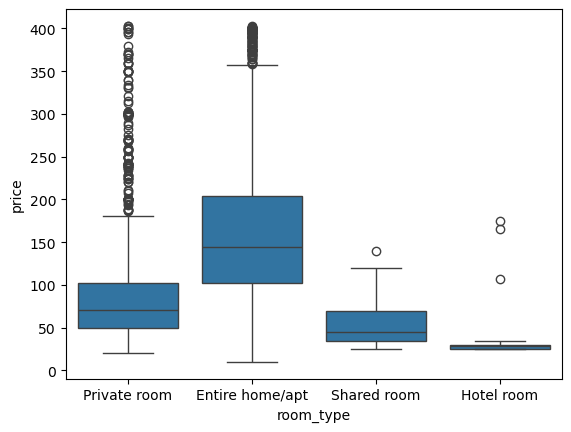

In [30]:
sns.boxplot(x='room_type', y='price', data=df)

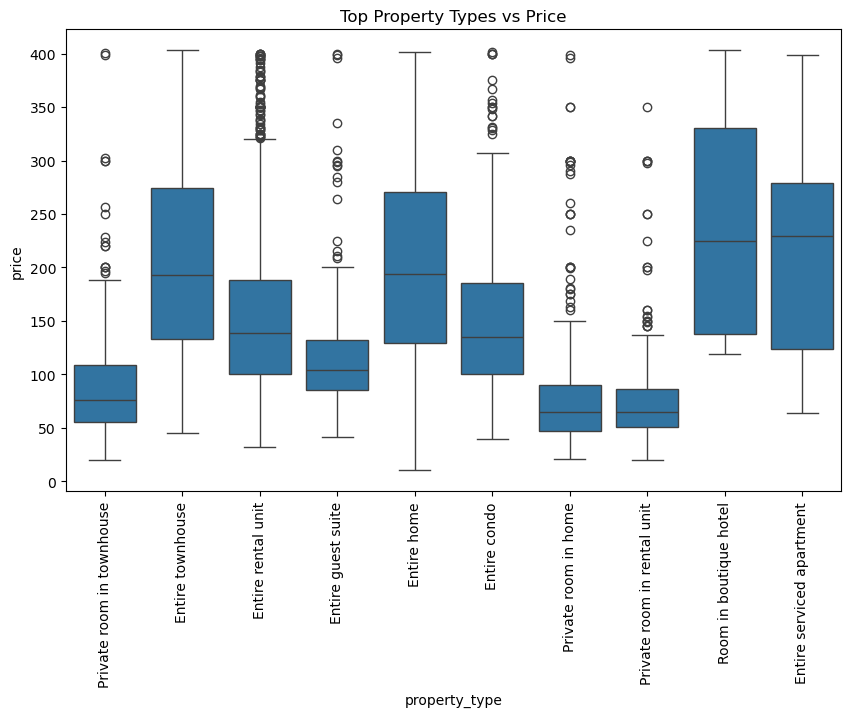

In [31]:
top_property = df['property_type'].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.boxplot(x='property_type',
            y='price',
            data=df[df['property_type'].isin(top_property)])
plt.xticks(rotation=90)
plt.title("Top Property Types vs Price")
plt.show()

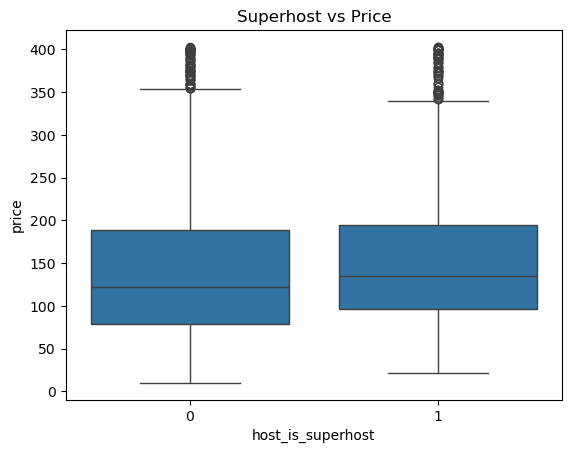

In [32]:
sns.boxplot(x='host_is_superhost', y='price', data=df)
plt.title("Superhost vs Price")
plt.show()

In [33]:
# STEP 11: One-Hot Encoding of Categorical Variables
df = pd.get_dummies(
    df,
    columns=[
        'room_type',
        'property_type',
        'neighbourhood_cleansed',
        'host_response_time'
    ],
    drop_first=True
)

In [34]:
df.head()

,host_id,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,latitude,...,"neighbourhood_cleansed_Takoma, Brightwood, Manor Park","neighbourhood_cleansed_Twining, Fairlawn, Randle Highlands, Penn Branch, Fort Davis Park, Fort Dupont","neighbourhood_cleansed_Union Station, Stanton Park, Kingman Park","neighbourhood_cleansed_West End, Foggy Bottom, GWU","neighbourhood_cleansed_Woodland/Fort Stanton, Garfield Heights, Knox Hill","neighbourhood_cleansed_Woodridge, Fort Lincoln, Gateway",host_response_time_a few days or more,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour
0,120875011,100.0,98.0,0,1,2,"['email', 'phone']",1,0,38.922170,...,False,False,False,False,False,False,False,False,False,False
1,55133178,100.0,100.0,0,1,2,"['email', 'phone']",1,1,38.863400,...,False,False,False,False,False,False,False,False,False,True
2,39930655,99.0,100.0,0,251,289,"['email', 'phone']",1,1,38.907050,...,False,False,False,False,False,False,False,False,False,True
3,351398058,100.0,100.0,1,3,4,"['email', 'phone']",1,1,38.910320,...,False,False,False,False,False,False,False,False,False,True
4,395672427,100.0,98.0,0,1408,2586,"['email', 'phone']",1,0,38.876301,...,False,False,False,False,False,False,False,False,False,False


In [35]:
# STEP 12: Convert host_verifications List → Numeric Count
if 'host_verifications' in df.columns:
    df['host_verifications_count'] = df['host_verifications'].apply(
        lambda x: len(eval(x)) if isinstance(x, str) else 0
    )
    df.drop(columns=['host_verifications'], inplace=True)

In [36]:
df.head()

,host_id,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,...,"neighbourhood_cleansed_Twining, Fairlawn, Randle Highlands, Penn Branch, Fort Davis Park, Fort Dupont","neighbourhood_cleansed_Union Station, Stanton Park, Kingman Park","neighbourhood_cleansed_West End, Foggy Bottom, GWU","neighbourhood_cleansed_Woodland/Fort Stanton, Garfield Heights, Knox Hill","neighbourhood_cleansed_Woodridge, Fort Lincoln, Gateway",host_response_time_a few days or more,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour,host_verifications_count
0,120875011,100.0,98.0,0,1,2,1,0,38.922170,-77.000450,...,False,False,False,False,False,False,False,False,False,2
1,55133178,100.0,100.0,0,1,2,1,1,38.863400,-76.991870,...,False,False,False,False,False,False,False,False,True,2
2,39930655,99.0,100.0,0,251,289,1,1,38.907050,-77.042370,...,False,False,False,False,False,False,False,False,True,2
3,351398058,100.0,100.0,1,3,4,1,1,38.910320,-77.020400,...,False,False,False,False,False,False,False,False,True,2
4,395672427,100.0,98.0,0,1408,2586,1,0,38.876301,-77.014702,...,False,False,False,False,False,False,False,False,False,2


In [37]:
# STEP 13: Drop Remaining Problematic Text Columns
# bathrooms_text is redundant (numeric bathrooms already exist)
df['bathrooms'] = df['bathrooms_text'].str.extract(r'(\d+\.?\d*)').astype(float)
if 'bathrooms_text' in df.columns:
    df.drop(columns=['bathrooms_text'], inplace=True)

# amenities must never be used as raw text
df['amenities_count'] = df['amenities'].apply(
    lambda x: len(eval(x)) if isinstance(x,str) else 0
)
if 'amenities' in df.columns:
    df.drop(columns=['amenities'], inplace=True)

In [38]:
df.head()

,host_id,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,...,"neighbourhood_cleansed_West End, Foggy Bottom, GWU","neighbourhood_cleansed_Woodland/Fort Stanton, Garfield Heights, Knox Hill","neighbourhood_cleansed_Woodridge, Fort Lincoln, Gateway",host_response_time_a few days or more,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour,host_verifications_count,bathrooms,amenities_count
0,120875011,100.0,98.0,0,1,2,1,0,38.922170,-77.000450,...,False,False,False,False,False,False,False,2,1.0,13
1,55133178,100.0,100.0,0,1,2,1,1,38.863400,-76.991870,...,False,False,False,False,False,False,True,2,2.5,57
2,39930655,99.0,100.0,0,251,289,1,1,38.907050,-77.042370,...,False,False,False,False,False,False,True,2,2.0,39
3,351398058,100.0,100.0,1,3,4,1,1,38.910320,-77.020400,...,False,False,False,False,False,False,True,2,1.0,8
4,395672427,100.0,98.0,0,1408,2586,1,0,38.876301,-77.014702,...,False,False,False,False,False,False,False,2,2.0,31


In [39]:
null_only_columns = df.columns[df.isnull().all()]
result = df[null_only_columns].isnull().sum()
print(result)

Series([], dtype: float64)


In [40]:
df.head()

,host_id,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,...,"neighbourhood_cleansed_West End, Foggy Bottom, GWU","neighbourhood_cleansed_Woodland/Fort Stanton, Garfield Heights, Knox Hill","neighbourhood_cleansed_Woodridge, Fort Lincoln, Gateway",host_response_time_a few days or more,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour,host_verifications_count,bathrooms,amenities_count
0,120875011,100.0,98.0,0,1,2,1,0,38.922170,-77.000450,...,False,False,False,False,False,False,False,2,1.0,13
1,55133178,100.0,100.0,0,1,2,1,1,38.863400,-76.991870,...,False,False,False,False,False,False,True,2,2.5,57
2,39930655,99.0,100.0,0,251,289,1,1,38.907050,-77.042370,...,False,False,False,False,False,False,True,2,2.0,39
3,351398058,100.0,100.0,1,3,4,1,1,38.910320,-77.020400,...,False,False,False,False,False,False,True,2,1.0,8
4,395672427,100.0,98.0,0,1408,2586,1,0,38.876301,-77.014702,...,False,False,False,False,False,False,False,2,2.0,31


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5990 entries, 0 to 6454
Columns: 137 entries, host_id to amenities_count
dtypes: bool(88), float64(23), int64(24), object(2)
memory usage: 2.8+ MB


In [42]:
df.describe(include='all')

,host_id,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,...,"neighbourhood_cleansed_West End, Foggy Bottom, GWU","neighbourhood_cleansed_Woodland/Fort Stanton, Garfield Heights, Knox Hill","neighbourhood_cleansed_Woodridge, Fort Lincoln, Gateway",host_response_time_a few days or more,host_response_time_within a day,host_response_time_within a few hours,host_response_time_within an hour,host_verifications_count,bathrooms,amenities_count
count,5.990000e+03,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,...,5990,5990,5990,5990,5990,5990,5990,5990.000000,5989.000000,5990.00000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,2,2,2,2,2,2,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,True,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5818,5983,5957,5942,5754,5184,3748,NaN,NaN,NaN
mean,1.191507e+08,97.961269,91.467279,0.308347,251.051419,320.451586,0.991319,0.871119,38.910270,-77.013879,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.177629,1.294039,33.06828
std,1.386429e+08,9.290178,17.179589,0.461849,927.643676,1074.403808,0.092775,0.335097,0.024631,0.030685,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.519611,0.661115,14.39158
min,4.492000e+03,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,38.819950,-77.112690,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.00000
25%,1.601717e+07,100.000000,94.000000,0.000000,1.000000,2.000000,1.000000,1.000000,38.897640,-77.033127,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,22.00000
50%,5.128240e+07,100.000000,98.000000,0.000000,3.000000,4.000000,1.000000,1.000000,38.909805,-77.015490,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,33.00000
75%,1.736167e+08,100.000000,100.000000,1.000000,24.000000,40.000000,1.000000,1.000000,38.923230,-76.994683,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.500000,43.00000


In [43]:
null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null %': (df.isnull().sum() / len(df)) * 100
})

null_summary[null_summary['Null Count'] > 0].sort_values(by='Null %', ascending=False)

,Null Count,Null %
bathrooms,1,0.016694


In [44]:
df.isnull().sum().sum()

np.int64(1)

## MISSING VALUE ANALYSIS

In [45]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}).sort_values(by="Missing %", ascending=False)

missing_df.head(20)

,Missing Count,Missing %
bathrooms,1,0.016694
host_response_rate,0,0.000000
host_acceptance_rate,0,0.000000
host_is_superhost,0,0.000000
host_listings_count,0,0.000000
host_total_listings_count,0,0.000000
host_has_profile_pic,0,0.000000
host_identity_verified,0,0.000000
host_id,0,0.000000
latitude,0,0.000000


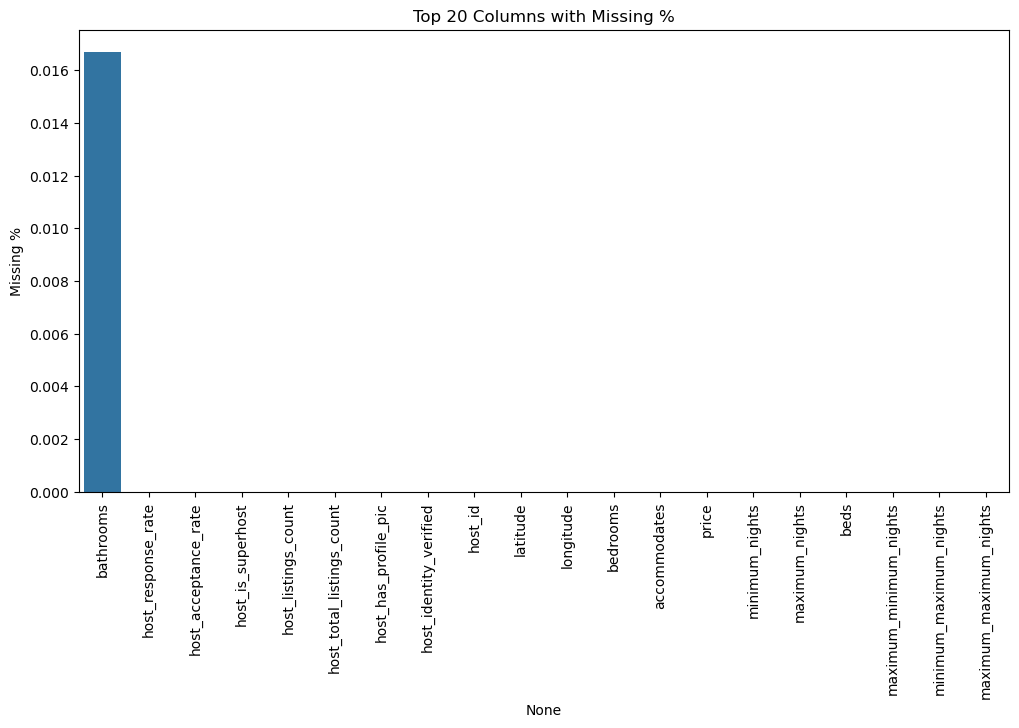

In [46]:
plt.figure(figsize=(12,6))
sns.barplot(x=missing_df.head(20).index,
            y=missing_df.head(20)['Missing %'])
plt.xticks(rotation=90)
plt.title("Top 20 Columns with Missing %")
plt.show()

## TARGET VARIABLE ANALYSIS (PRICE)

In [47]:
df['price'] = pd.to_numeric(
    df['price'].astype(str).str.replace('[$,]', '', regex=True),
    errors='coerce'
)

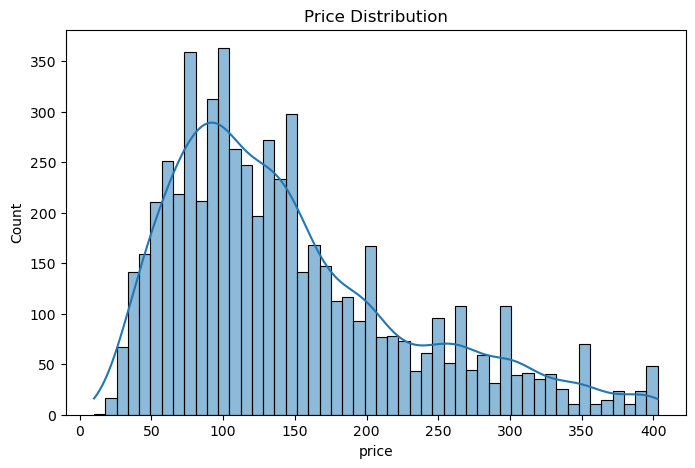

In [48]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()

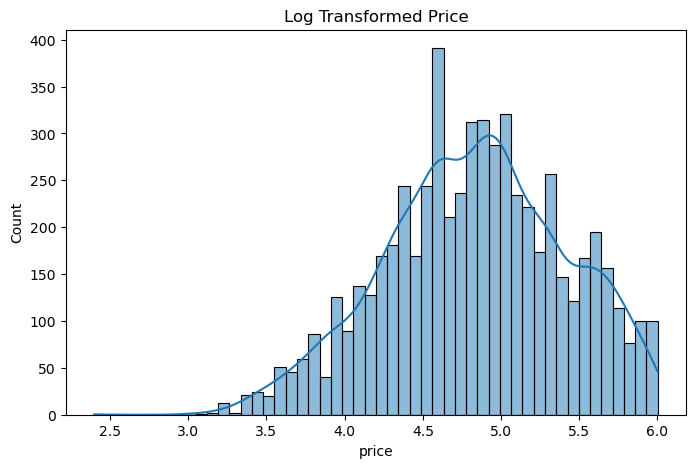

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['price']), bins=50, kde=True)
plt.title("Log Transformed Price")
plt.show()

## NUMERICAL FEATURE ANALYSIS

In [50]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].describe()

,host_id,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,...,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_experience_years,host_verifications_count,bathrooms,amenities_count
count,5.990000e+03,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,...,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,5990.000000,5989.000000,5990.00000
mean,1.191507e+08,97.961269,91.467279,0.308347,251.051419,320.451586,0.991319,0.871119,38.910270,-77.013879,...,0.259766,29.774624,22.665275,6.609516,0.392321,1.673005,9.841740,2.177629,1.294039,33.06828
std,1.386429e+08,9.290178,17.179589,0.461849,927.643676,1074.403808,0.092775,0.335097,0.024631,0.030685,...,0.438543,59.326832,52.969941,27.551157,2.043035,1.769386,2.940994,0.519611,0.661115,14.39158
min,4.492000e+03,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,38.819950,-77.112690,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000,2.978082,1.000000,0.000000,0.00000
25%,1.601717e+07,100.000000,94.000000,0.000000,1.000000,2.000000,1.000000,1.000000,38.897640,-77.033127,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.480000,8.046575,2.000000,1.000000,22.00000
50%,5.128240e+07,100.000000,98.000000,0.000000,3.000000,4.000000,1.000000,1.000000,38.909805,-77.015490,...,0.000000,2.000000,1.000000,0.000000,0.000000,1.190000,10.231507,2.000000,1.000000,33.00000
75%,1.736167e+08,100.000000,100.000000,1.000000,24.000000,40.000000,1.000000,1.000000,38.923230,-76.994683,...,1.000000,17.000000,7.000000,1.000000,0.000000,2.200000,11.778082,2.000000,1.500000,43.00000
max,5.058822e+08,100.000000,100.000000,1.000000,4807.000000,7800.000000,1.000000,1.000000,38.992720,-76.910920,...,1.000000,221.000000,221.000000,163.000000,20.000000,31.670000,17.304110,3.000000,8.000000,80.00000


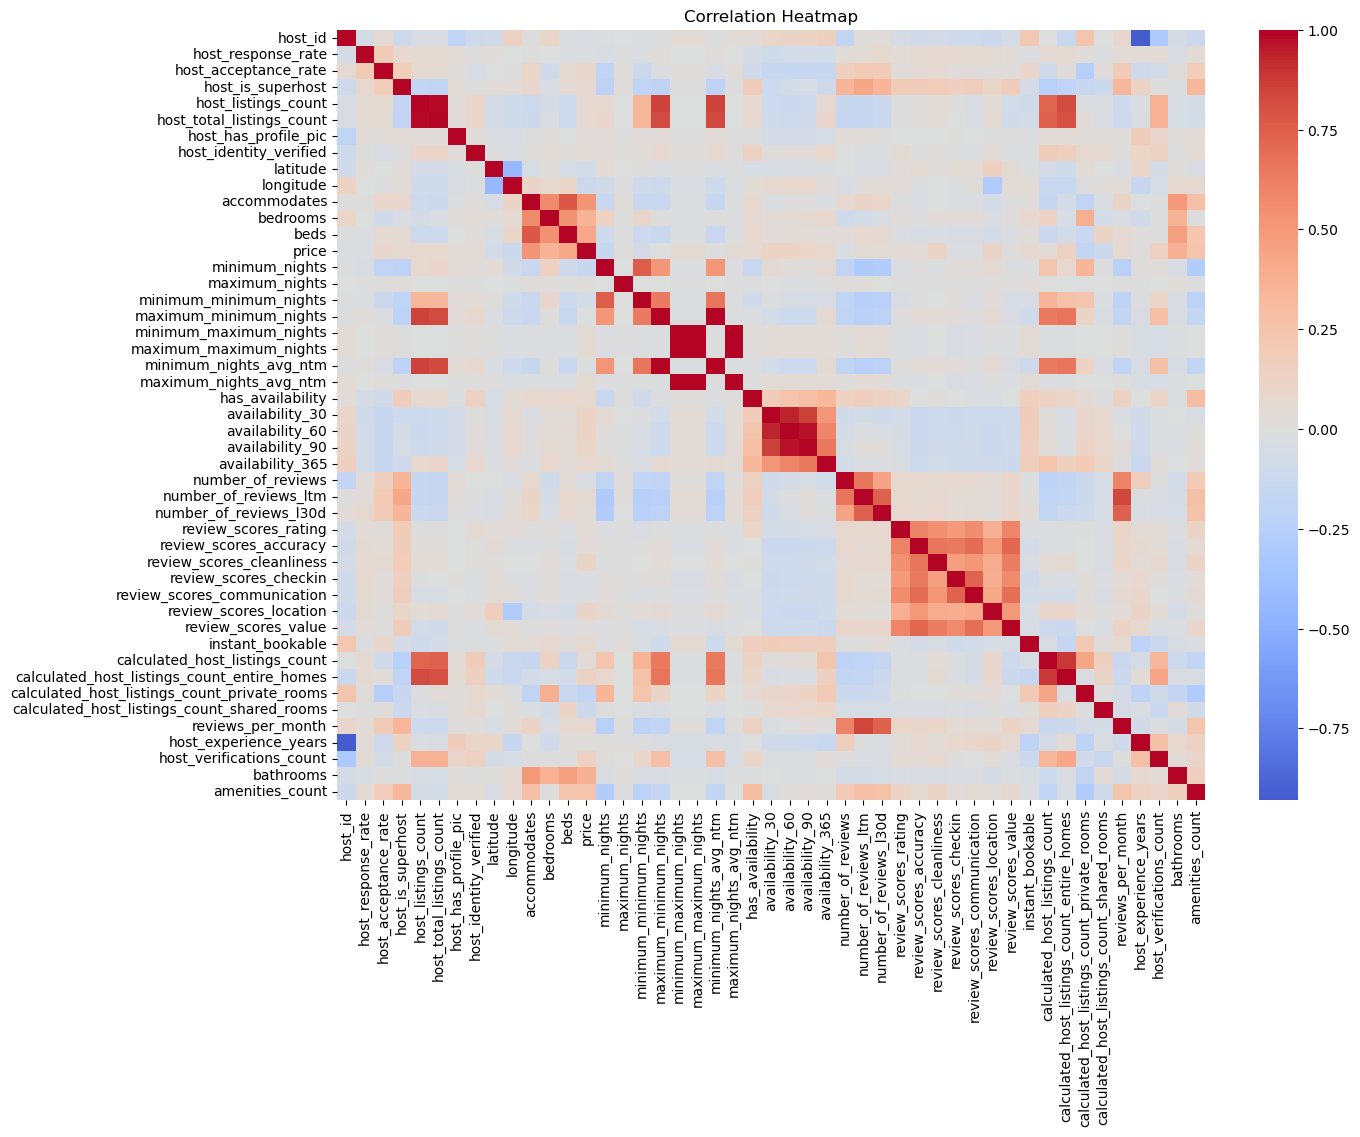

In [51]:
plt.figure(figsize=(14,10))
sns.heatmap(df[num_cols].corr(),
            cmap='coolwarm',
            center=0)
plt.title("Correlation Heatmap")
plt.show()

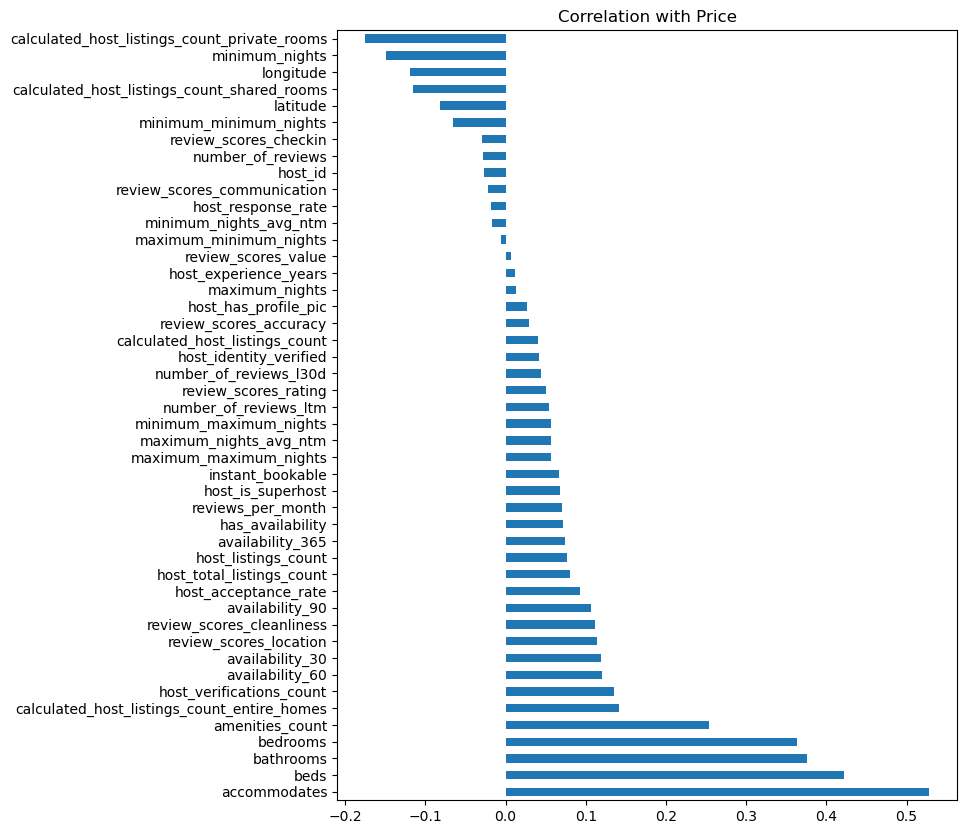

In [52]:
corr_price = df[num_cols].corr()['price'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
corr_price.drop('price').plot(kind='barh')
plt.title("Correlation with Price")
plt.show()

## LOCATION ANALYSIS

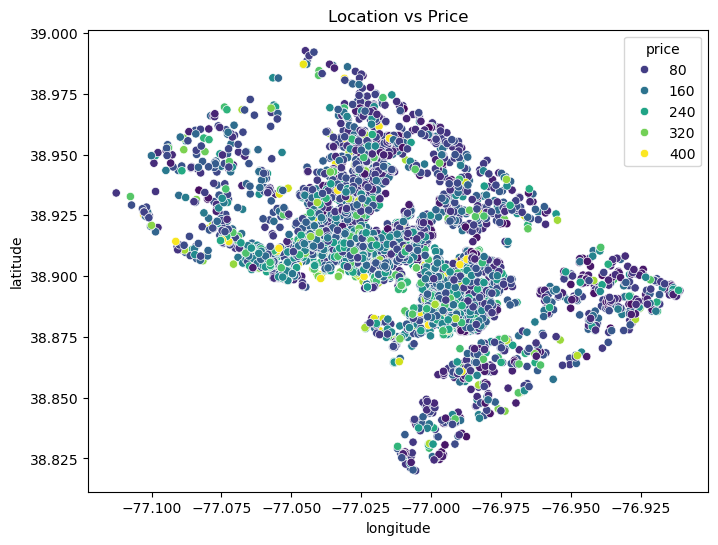

In [53]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='longitude',
                y='latitude',
                hue='price',
                data=df,
                palette='viridis')
plt.title("Location vs Price")
plt.show()

## AVAILABILITY ANALYSIS

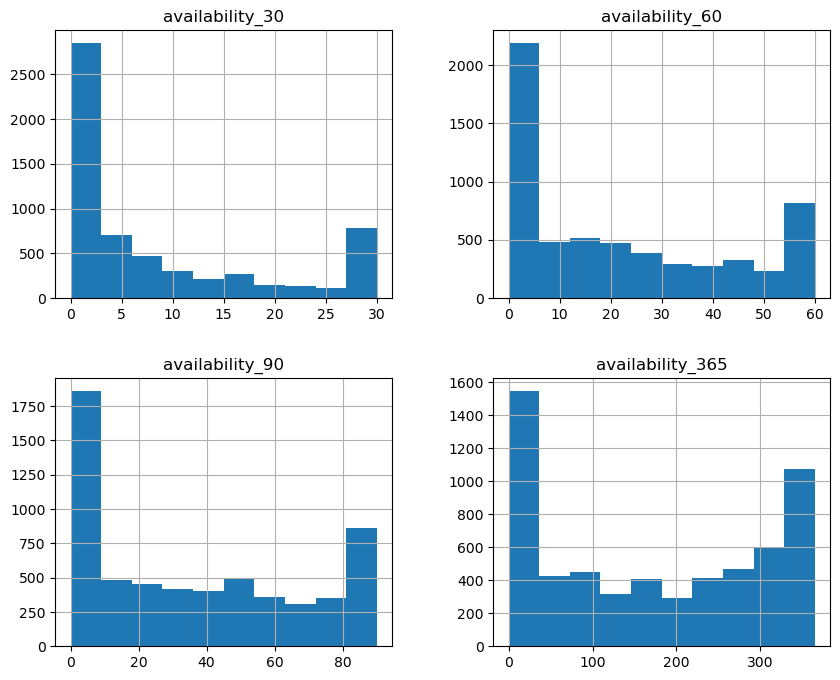

In [54]:
availability_cols = [
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_365'
]

df[availability_cols].hist(figsize=(10,8))
plt.show()


## REVIEW ANALYSIS

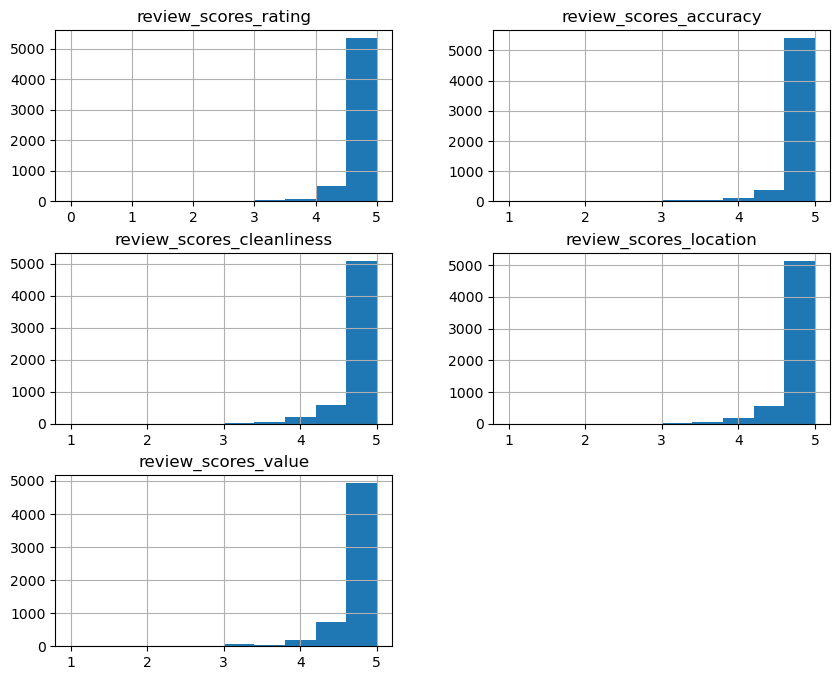

In [55]:
review_cols = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_location',
    'review_scores_value'
]

df[review_cols].hist(figsize=(10,8))
plt.show()

## FEATURE ENGINEERING

In [56]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
df['review_recency_days'] = (
    (pd.Timestamp.today() - df['last_review']).dt.days
)

In [57]:
df['host_listing_ratio'] = (
    df['host_total_listings_count'] /
    df['calculated_host_listings_count']
)

In [58]:
df['availability_ratio'] = df['availability_365'] / 365

In [59]:
drop_cols = ['first_review','last_review']
df.drop(columns=drop_cols, inplace=True)

In [60]:
corr = df.corr()
corr_target = abs(corr['price'])

relevant_features = corr_target[corr_target > 0.02]
df = df[relevant_features.index]

In [61]:
X = df.drop('price', axis=1)
y = df['price']

In [62]:
# Keep only numeric features
X = X.select_dtypes(include=['int64', 'float64'])

In [63]:
# Handle Infinite & NaN (Safely)
data = pd.concat([X, y], axis=1)

data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

X = data.drop('price', axis=1)
y = data['price']

In [64]:
# Remove Low Variance Features
selector = VarianceThreshold(threshold=0.01)

X = pd.DataFrame(
    selector.fit_transform(X),
    columns=X.columns[selector.get_support()]
)

print("Features after variance removal:", X.shape[1])

Features after variance removal: 40


In [65]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

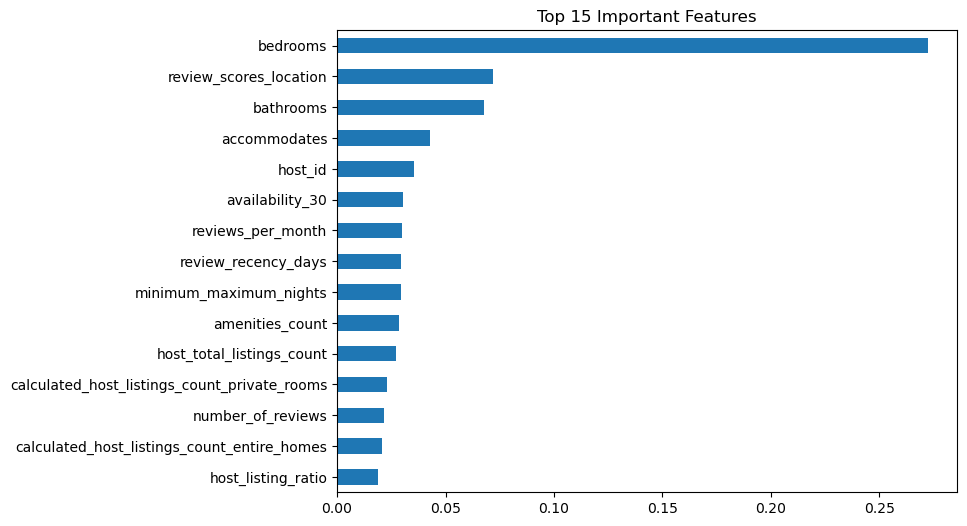

In [67]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns)

top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 15 Important Features")
plt.show()

In [68]:
# Keep Only Top 15 Features
important_columns = top_features.index

X = X[important_columns]

In [69]:
important_columns

Index(['bedrooms', 'review_scores_location', 'bathrooms', 'accommodates',
       'host_id', 'availability_30', 'reviews_per_month',
       'review_recency_days', 'minimum_maximum_nights', 'amenities_count',
       'host_total_listings_count',
       'calculated_host_listings_count_private_rooms', 'number_of_reviews',
       'calculated_host_listings_count_entire_homes', 'host_listing_ratio'],
      dtype='object')

In [70]:
selected_columns = [
    'bedrooms',
    'bathrooms',
    'accommodates',
    'review_scores_location',
    'amenities_count',
    'availability_30',
    'reviews_per_month',
    'number_of_reviews',
    'host_listing_ratio'
]

X = X[selected_columns]

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [72]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

In [74]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(kernel='rbf')
}

In [75]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

results_df.sort_values(by="R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
5,Gradient Boosting,39.536109,55.363046,0.549025
4,Random Forest,39.794697,55.489192,0.546967
1,Ridge Regression,46.516554,62.912160,0.417653
2,Lasso Regression,46.516039,62.913763,0.417623
0,Linear Regression,46.515893,62.913819,0.417622
3,Decision Tree,56.062171,81.162218,0.030784
6,SVR,61.051260,83.558430,-0.027290


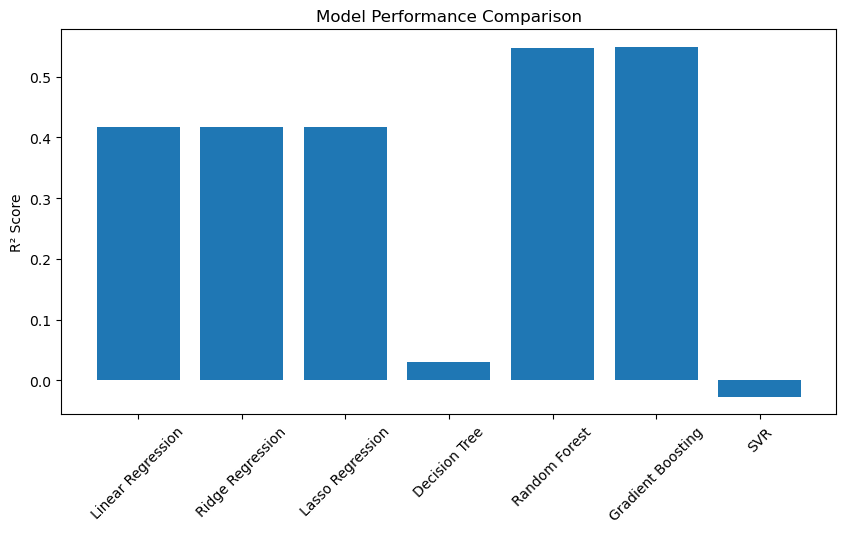

In [76]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xticks(rotation=45)
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.show()

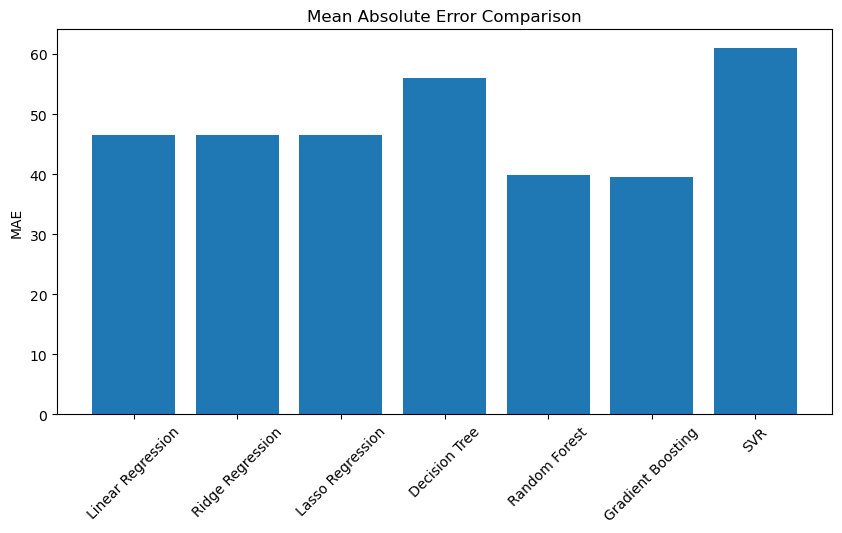

In [77]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.xticks(rotation=45)
plt.ylabel("MAE")
plt.title("Mean Absolute Error Comparison")
plt.show()

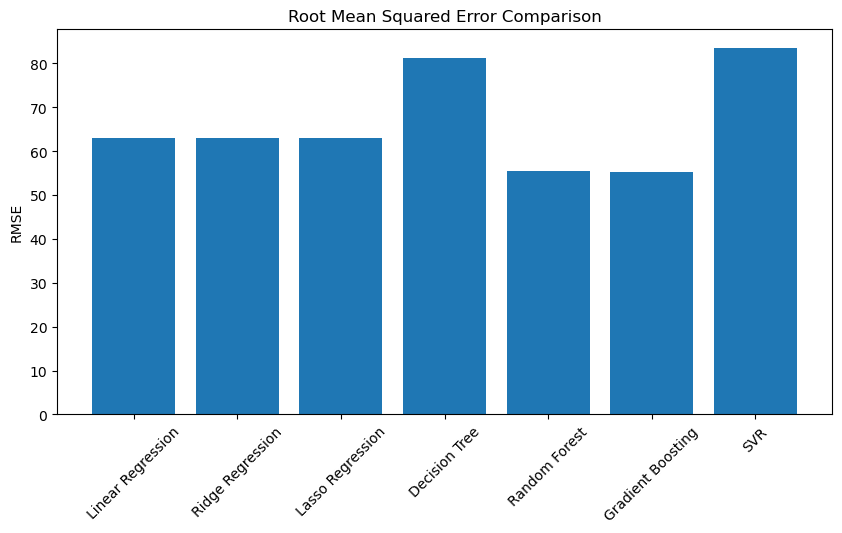

In [78]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("Root Mean Squared Error Comparison")
plt.show()

In [79]:
best_model = results_df.sort_values(by="R2 Score", ascending=False).iloc[0]
best_model

Model       Gradient Boosting
MAE                 39.536109
RMSE                55.363046
R2 Score             0.549025
Name: 5, dtype: object

In [80]:
from sklearn.model_selection import GridSearchCV, cross_val_score

In [81]:
# Baseline Gradient Boosting Model
gb_baseline = GradientBoostingRegressor(random_state=42)

gb_baseline.fit(X_train, y_train)
y_pred_baseline = gb_baseline.predict(X_test)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("Baseline Model Performance")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)
print("R2 Score:", baseline_r2)

Baseline Model Performance
MAE: 39.53610872083905
RMSE: 55.36304602500209
R2 Score: 0.5490249332387358


In [82]:
cv_scores = cross_val_score(
    gb_baseline,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross-Validation R2 Scores:", cv_scores)
print("Average CV R2 Score:", np.mean(cv_scores))

Cross-Validation R2 Scores: [0.58357732 0.56840471 0.49961227 0.56882773 0.50953456]
Average CV R2 Score: 0.5459913176613755


In [83]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [84]:
gb_model = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 4],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [85]:
print("Best Parameters Found:")
print(grid_search.best_params_)

print("Best Cross-Validated R2 Score:")
print(grid_search.best_score_)

Best Parameters Found:
{'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validated R2 Score:
0.5666553341807482


In [86]:
best_gb_model = grid_search.best_estimator_

y_pred_tuned = best_gb_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Model Performance")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R2 Score:", tuned_r2)

Tuned Model Performance
MAE: 38.721684241690255
RMSE: 54.74377645814979
R2 Score: 0.5590573726549118


In [87]:
print("Performance Comparison")
print("Baseline R2 Score:", baseline_r2)
print("Tuned R2 Score:", tuned_r2)

Performance Comparison
Baseline R2 Score: 0.5490249332387358
Tuned R2 Score: 0.5590573726549118
